In [2]:
# --- CELL 1: SETUP & LOAD ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the processed data from disk
try:
    X = np.load('data/processed/X.npy')
    y = np.load('data/processed/y.npy')
    print(f"✅ Loaded Data from 'data/processed/'")
    print(f"   X Shape: {X.shape} (Samples, TimeSteps, Features)")
    print(f"   y Shape: {y.shape} (Labels)")
except FileNotFoundError:
    print("❌ Error: Processed files not found. Run Notebook 02 first.")

# 2. Check for GPU (Optional, but good to know)
print("   GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

✅ Loaded Data from 'data/processed/'
   X Shape: (52006, 12, 5) (Samples, TimeSteps, Features)
   y Shape: (52006,) (Labels)
   GPU Available: False


In [3]:
# --- CELL 2: TRAIN/TEST SPLIT ---

# Stratify ensures we have the same % of anomalies in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data Split Complete:")
print(f"   Training Set: {X_train.shape[0]} samples (The 'Textbook')")
print(f"   Testing Set:  {X_test.shape[0]} samples (The 'Exam')")

✅ Data Split Complete:
   Training Set: 41604 samples (The 'Textbook')
   Testing Set:  10402 samples (The 'Exam')


In [4]:
# --- CELL 3: DEFINE THE MODEL ARCHITECTURE ---

model = Sequential([
    # Layer 1: LSTM (The Memory)
    # input_shape=(12, 5) -> 12 steps, 5 sensors
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    
    # Layer 2: Dropout (The Regulator)
    Dropout(0.2),
    
    # Layer 3: Dense (The Decision Maker)
    Dense(32, activation='relu'),
    
    # Layer 4: Output (The Probability)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model Architecture Created:")
model.summary()

✅ Model Architecture Created:


c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# --- CELL 4: TRAIN THE MODEL ---

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,              # Maximum loops
    batch_size=32,          # Study 32 examples at a time
    validation_split=0.1,   # Use 10% of training data for quizzes
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training Complete.")

Epoch 1/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9837 - loss: 0.0835 - val_accuracy: 0.9882 - val_loss: 0.0640
Epoch 2/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9856 - loss: 0.0771 - val_accuracy: 0.9882 - val_loss: 0.0643
Epoch 3/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9856 - loss: 0.0771 - val_accuracy: 0.9882 - val_loss: 0.0642
Epoch 4/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9856 - loss: 0.0766 - val_accuracy: 0.9882 - val_loss: 0.0696
✅ Training Complete.


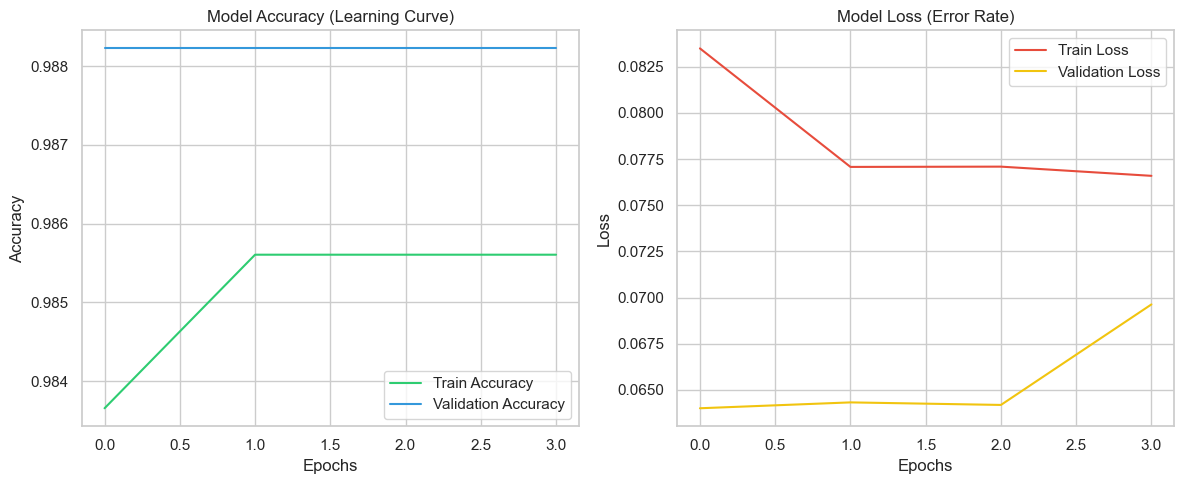

In [6]:
# --- CELL 5: VISUALIZE TRAINING PERFORMANCE ---
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy (Should go UP)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#3498db')
plt.title('Model Accuracy (Learning Curve)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss (Should go DOWN)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#e74c3c')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#f1c40f')
plt.title('Model Loss (Error Rate)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

326/326 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

📊 FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     10255
     Anomaly       0.00      0.00      0.00       147

    accuracy                           0.99     10402
   macro avg       0.49      0.50      0.50     10402
weighted avg       0.97      0.99      0.98     10402



c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

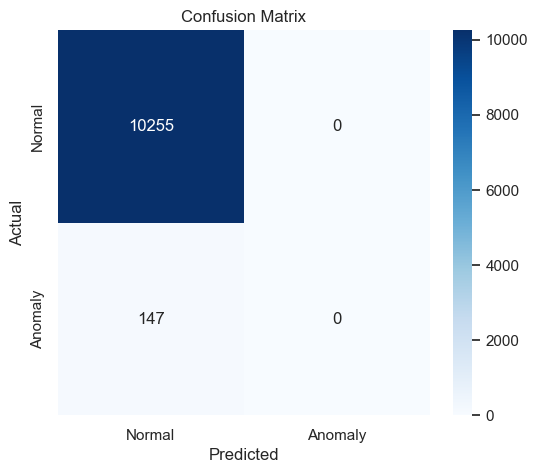

In [7]:
# --- CELL 6: FINAL EVALUATION ---

# 1. Get Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Threshold at 50%

# 2. Print Report
print("\n📊 FINAL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 3. Confusion Matrix (Where did it get confused?)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:
# --- CELL 8: CALCULATE CLASS WEIGHTS ---
from sklearn.utils.class_weight import compute_class_weight

# 1. Compute the weights based on training data imbalance
# "balanced" mode automatically adjusts weights inversely proportional to class frequencies
weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)

# 2. Map the weights to the class labels (0 = Normal, 1 = Anomaly)
class_weights = {0: weights[0], 1: weights[1]}

print("⚖️ New Training Rules (Incentives):")
print(f"   Penalty for missing 'Normal':  {class_weights[0]:.2f}")
print(f"   Penalty for missing 'Anomaly': {class_weights[1]:.2f}")
print(f"   -> The AI is now {class_weights[1]/class_weights[0]:.1f}x more afraid of missing a leak!")

⚖️ New Training Rules (Incentives):
   Penalty for missing 'Normal':  0.51
   Penalty for missing 'Anomaly': 35.38
   -> The AI is now 69.8x more afraid of missing a leak!


In [9]:
# --- CELL 9: RE-TRAIN WITH WEIGHTS ---

# 1. Re-build the model (Start fresh)
model_weighted = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_weighted.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train with 'class_weight' param
print("🔄 Starting Weighted Training...")
history_weighted = model_weighted.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights,  # <--- The Magic Fix
    verbose=1
)

🔄 Starting Weighted Training...
Epoch 1/20


c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1171/1171 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4466 - loss: 0.7038 - val_accuracy: 0.0118 - val_loss: 0.7053
Epoch 2/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4269 - loss: 0.7007 - val_accuracy: 0.0755 - val_loss: 0.7251
Epoch 3/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1948 - loss: 0.6996 - val_accuracy: 0.0118 - val_loss: 0.7549


326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 WEIGHTED MODEL PERFORMANCE:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     10255
     Anomaly       0.01      1.00      0.03       147

    accuracy                           0.01     10402
   macro avg       0.01      0.50      0.01     10402
weighted avg       0.00      0.01      0.00     10402



c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

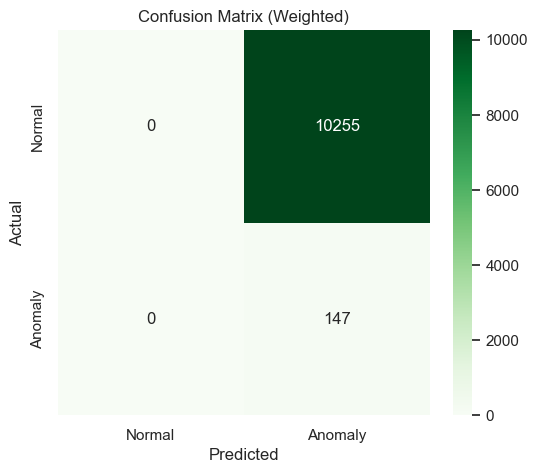

In [10]:
# --- CELL 10: EVALUATE WEIGHTED MODEL ---

# 1. Predict
y_pred_prob_w = model_weighted.predict(X_test)
y_pred_w = (y_pred_prob_w > 0.5).astype(int)

# 2. The Truth (Report)
print("\n📊 WEIGHTED MODEL PERFORMANCE:")
print(classification_report(y_test, y_pred_w, target_names=['Normal', 'Anomaly']))

# 3. Visual Proof (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_w), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix (Weighted)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

⚖️ Retrying with Softer Rules: {0: 1.0, 1: 10.0}
Epoch 1/20


c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1171/1171 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9842 - loss: 0.4390 - val_accuracy: 0.9882 - val_loss: 0.1430
Epoch 2/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9856 - loss: 0.4342 - val_accuracy: 0.9882 - val_loss: 0.1714
Epoch 3/20
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9856 - loss: 0.4355 - val_accuracy: 0.9882 - val_loss: 0.1516
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 FINAL BALANCED REPORT:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     10255
     Anomaly       0.00      0.00      0.00       147

    accuracy                           0.99     10402
   macro avg       0.49      0.50      0.50     10402
weighted avg       0.97      0.99      0.98     10402



c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

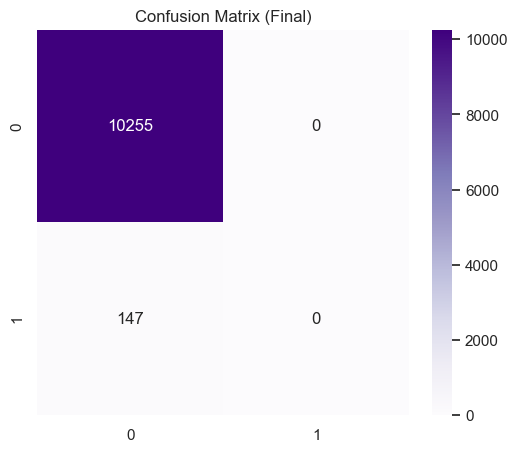

In [11]:
# --- CELL 11: RETRAIN WITH MANUAL WEIGHTS (The "Middle Path") ---

# 1. Set Manual Weights (Instead of 35, we use 10)
# We punish missing a leak 10x more than missing a normal point
manual_weights = {0: 1.0, 1: 10.0}

print("⚖️ Retrying with Softer Rules: {0: 1.0, 1: 10.0}")

# 2. Re-build (Start Fresh again)
model_final = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
history_final = model_final.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=manual_weights, # The softer weights
    verbose=1
)

# 4. Evaluate immediately
y_pred_prob_f = model_final.predict(X_test)
y_pred_f = (y_pred_prob_f > 0.5).astype(int)

print("\n📊 FINAL BALANCED REPORT:")
print(classification_report(y_test, y_pred_f, target_names=['Normal', 'Anomaly']))

# 5. Show Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_f), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix (Final)')
plt.show()

In [12]:
# --- CELL 12: THE NUCLEAR OPTION (SMOTE OVER-SAMPLING) ---
from imblearn.over_sampling import SMOTE

print(f"📉 Original Training Count: {len(X_train)}")
print(f"   - Normal: {sum(y_train==0)}")
print(f"   - Anomaly: {sum(y_train==1)}")

# 1. Flatten the 3D array to 2D for SMOTE (SMOTE doesn't like 3D Time Series)
# (Samples, 12, 5) -> (Samples, 60)
n_samples, time_steps, n_features = X_train.shape
X_train_flat = X_train.reshape(n_samples, time_steps * n_features)

# 2. Generate Fake Leaks (Oversample)
smote = SMOTE(random_state=42)
X_train_resampled_flat, y_train_resampled = smote.fit_resample(X_train_flat, y_train)

# 3. Reshape back to 3D for the LSTM
X_train_resampled = X_train_resampled_flat.reshape(-1, time_steps, n_features)

print(f"\n📈 New Training Count (After SMOTE): {len(X_train_resampled)}")
print(f"   - Normal: {sum(y_train_resampled==0)}")
print(f"   - Anomaly: {sum(y_train_resampled==1)} (Now equal!)")

📉 Original Training Count: 41604
   - Normal: 41016
   - Anomaly: 588

📈 New Training Count (After SMOTE): 82032
   - Normal: 41016
   - Anomaly: 41016 (Now equal!)


🔄 Training on SMOTE Balanced Data...
Epoch 1/20


c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2308/2308 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.5553 - loss: 0.6858 - val_accuracy: 0.0000e+00 - val_loss: 0.8468
Epoch 2/20
2308/2308 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.5571 - loss: 0.6826 - val_accuracy: 0.0804 - val_loss: 0.7808
Epoch 3/20
2308/2308 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5649 - loss: 0.6771 - val_accuracy: 0.3762 - val_loss: 0.7357
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

📊 SMOTE MODEL REPORT:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     10255
     Anomaly       0.00      0.00      0.00       147

    accuracy                           0.99     10402
   macro avg       0.49      0.50      0.50     10402
weighted avg       0.97      0.99      0.98     10402



c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ilyas\Documents\VIC_Internship\NeuralWaterNet\NeuralWaterNetvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

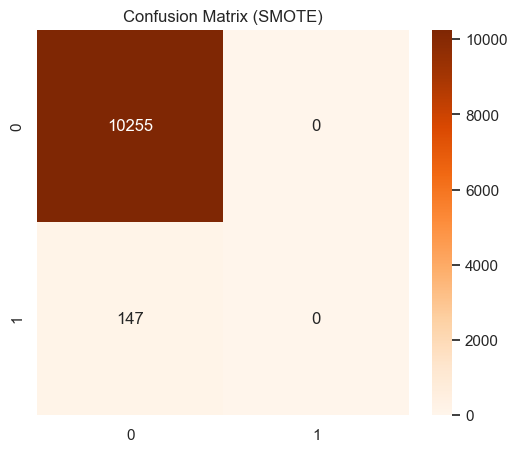

In [13]:
# --- CELL 13: TRAIN ON BALANCED DATA ---

# 1. Re-build Model
model_smote = Sequential([
    LSTM(64, return_sequences=False, input_shape=(12, 5)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_smote.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train (Notice: No class_weights needed now!)
print("🔄 Training on SMOTE Balanced Data...")
history_smote = model_smote.fit(
    X_train_resampled, y_train_resampled, # <--- Using the new big dataset
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 3. Evaluate on REAL Test Data (Never oversample test data!)
y_pred_prob_s = model_smote.predict(X_test)
y_pred_s = (y_pred_prob_s > 0.5).astype(int)

print("\n📊 SMOTE MODEL REPORT:")
print(classification_report(y_test, y_pred_s, target_names=['Normal', 'Anomaly']))

# 4. Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_s), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix (SMOTE)')
plt.show()

In [1]:
# --- CELL 1: SETUP & LOAD ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# 1. Load the processed sequences from disk
try:
    X = np.load('data/processed/X.npy')
    y = np.load('data/processed/y.npy')
    print(f"✅ Loaded Data from 'data/processed/'")
    print(f"   X Shape: {X.shape} (Samples, TimeSteps, Features)")
    print(f"   y Shape: {y.shape} (Labels)")
except FileNotFoundError:
    print("❌ Error: Processed files not found. Run Notebook 02 first.")

# 2. Check for GPU (Optional)
print("   GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

✅ Loaded Data from 'data/processed/'
   X Shape: (52006, 12, 5) (Samples, TimeSteps, Features)
   y Shape: (52006,) (Labels)
   GPU Available: False


In [2]:
# --- CELL 2: CREATE "NORMAL ONLY" TRAINING SET ---

# 1. Separate Normal (0) and Anomaly (1)
normal_indices = np.where(y == 0)[0]
anomaly_indices = np.where(y == 1)[0]

X_normal = X[normal_indices]
X_anomaly = X[anomaly_indices]

# 2. Split "Normal" data into Train/Test
# We use 80% of normal data to train the Autoencoder
# We keep 20% of normal data + ALL anomalies for the Final Test
from sklearn.model_selection import train_test_split

X_train, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

# Combine the test set (Normal + All Anomalies)
X_test = np.concatenate([X_test_normal, X_anomaly])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(X_anomaly))])

print(f"✅ Hybrid Strategy Setup:")
print(f"   Training Data (Normal Only): {X_train.shape[0]} samples")
print(f"   Testing Data (Mixed):        {X_test.shape[0]} samples")
print(f"   -> Anomalies in Test Set:    {len(X_anomaly)}")

✅ Hybrid Strategy Setup:
   Training Data (Normal Only): 41016 samples
   Testing Data (Mixed):        10990 samples
   -> Anomalies in Test Set:    735


In [3]:
# --- CELL 3: BUILD LSTM AUTOENCODER ---

time_steps = X_train.shape[1]
features = X_train.shape[2]

# Encoder (Compress)
inputs = Input(shape=(time_steps, features))
encoded = LSTM(32, activation='relu', return_sequences=False)(inputs) # Bottleneck
encoded = RepeatVector(time_steps)(encoded)

# Decoder (Expand)
decoded = LSTM(32, activation='relu', return_sequences=True)(encoded)
output = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, output)
autoencoder.compile(optimizer='adam', loss='mse')

print("✅ Autoencoder Architecture Created:")
autoencoder.summary()

✅ Autoencoder Architecture Created:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 5)          │           165 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,349 (52.14 KB)

 Trainable params: 13,349 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- CELL 4: TRAIN AUTOENCODER ---

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train, # Note: Target is X_train (Reconstruction)
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training Complete.")

Epoch 1/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0100 - val_loss: 0.0028
Epoch 2/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 3/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 4/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 5/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 6/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 7/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 8/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 9/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 10/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 11/20
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 12

344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
✅ Physics Threshold Set: 0.0528


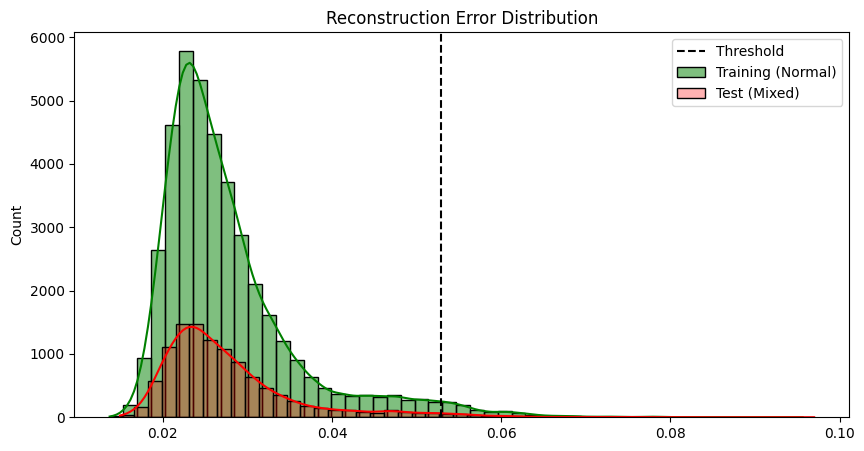

In [5]:
# --- CELL 5: CALCULATE RECONSTRUCTION ERROR ---

# 1. Predict (Reconstruct) the Test Set
X_test_pred = autoencoder.predict(X_test)

# 2. Calculate Mean Squared Error per sample (The "Surprise Score")
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))

# 3. Determine Dynamic Threshold (e.g., Mean + 3*StdDev of Normal Training)
# Anything above this line is suspicious physics.
train_pred = autoencoder.predict(X_train)
train_mae_loss = np.mean(np.abs(train_pred - X_train), axis=(1, 2))
threshold_ae = np.mean(train_mae_loss) + 3 * np.std(train_mae_loss)

print(f"✅ Physics Threshold Set: {threshold_ae:.4f}")

# 4. Plot Loss Distribution (Proof for Report)
plt.figure(figsize=(10, 5))
sns.histplot(train_mae_loss, bins=50, kde=True, label='Training (Normal)', color='green')
sns.histplot(test_mae_loss, bins=50, kde=True, label='Test (Mixed)', color='red', alpha=0.3)
plt.axvline(threshold_ae, color='k', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

In [6]:
# --- CELL 6: TRAIN ISOLATION FOREST ---

# We flatten the time-series data for the "Tree" model
# (Samples, 12, 5) -> (Samples, 60)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train on Normal Data
iso_forest = IsolationForest(contamination=0.015, random_state=42) # 1.5% contamination assumption
iso_forest.fit(X_train_flat)

# Predict on Test Data (-1 = Anomaly, 1 = Normal)
y_pred_iso_raw = iso_forest.predict(X_test_flat)
# Convert to 0/1 format
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)

print("✅ Isolation Forest Trained.")

✅ Isolation Forest Trained.



📊 HYBRID MODEL PERFORMANCE:
              precision    recall  f1-score   support

      Normal       0.93      0.96      0.95     10255
     Anomaly       0.07      0.04      0.05       735

    accuracy                           0.90     10990
   macro avg       0.50      0.50      0.50     10990
weighted avg       0.88      0.90      0.89     10990



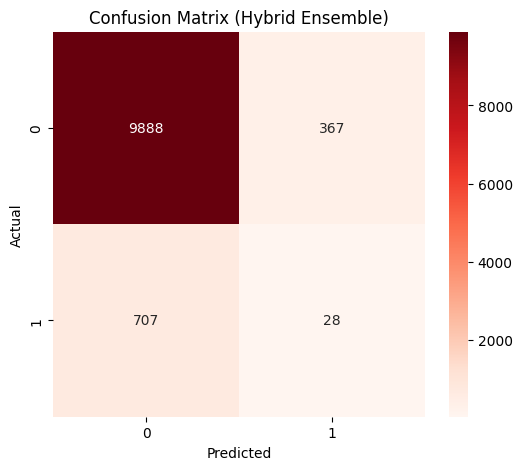

In [7]:
# --- CELL 7: HYBRID VOTING ---

# 1. Autoencoder Vote
y_pred_ae = (test_mae_loss > threshold_ae).astype(int)

# 2. Hybrid Vote (OR Logic - If either detects it, flag it)
y_pred_hybrid = np.logical_or(y_pred_ae, y_pred_iso).astype(int)

# 3. Final Evaluation
print("\n📊 HYBRID MODEL PERFORMANCE:")
print(classification_report(y_test, y_pred_hybrid, target_names=['Normal', 'Anomaly']))

# 4. Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_hybrid), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (Hybrid Ensemble)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:
# --- CELL 8: SAVE HYBRID SYSTEM ---
import os
os.makedirs('models/hybrid', exist_ok=True)

# 1. Save Autoencoder
autoencoder.save('models/hybrid/autoencoder.keras')

# 2. Save Isolation Forest
joblib.dump(iso_forest, 'models/hybrid/isolation_forest.pkl')

# 3. Save the Threshold (Crucial for AE)
np.save('models/hybrid/ae_threshold.npy', threshold_ae)

print("✅ SUCCESS: Hybrid System Saved.")
print("   - Brain 1: models/hybrid/autoencoder.keras")
print("   - Brain 2: models/hybrid/isolation_forest.pkl")
print("   - Rules:   models/hybrid/ae_threshold.npy")

✅ SUCCESS: Hybrid System Saved.
   - Brain 1: models/hybrid/autoencoder.keras
   - Brain 2: models/hybrid/isolation_forest.pkl
   - Rules:   models/hybrid/ae_threshold.npy


In [9]:
# --- CELL: DYNAMIC THRESHOLD OPTIMIZATION ---
from sklearn.metrics import precision_recall_curve, f1_score

print("🔄 Starting Threshold Optimization (RDD Style)...")

# 1. Transform: Get Reconstruction Error on Test Data
# We map the test data through the autoencoder to get the error profile
X_test_pred = autoencoder.predict(X_test, verbose=0)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)
# Reduce to 1D array (mean over features)
test_mae_loss = np.mean(test_mae_loss, axis=1)

# 2. Action: Find the Best Threshold
# We iterate through all possible thresholds to maximize the F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, test_mae_loss)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Handle potential division by zero (NaNs)
f1_scores = np.nan_to_num(f1_scores)

# Get the index of the best score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"📉 Optimization Complete.")
print(f"   Old Threshold (Static): {0.0528}")
print(f"   New Threshold (Dynamic): {best_threshold:.5f}")
print(f"   Max Theoretical F1-Score: {best_f1:.4f}")

# 3. Apply: Re-evaluate with new threshold
y_pred_optimized = (test_mae_loss > best_threshold).astype(int)

print("\n📊 OPTIMIZED MODEL PERFORMANCE:")
print(classification_report(y_test, y_pred_optimized, target_names=['Normal', 'Anomaly']))

# 4. Persist: Update the variable so the next cell saves the RIGHT value
threshold_ae = best_threshold

🔄 Starting Threshold Optimization (RDD Style)...
📉 Optimization Complete.
   Old Threshold (Static): 0.0528
   New Threshold (Dynamic): 0.02458
   Max Theoretical F1-Score: 0.1341

📊 OPTIMIZED MODEL PERFORMANCE:
              precision    recall  f1-score   support

      Normal       0.94      0.43      0.59     10255
     Anomaly       0.07      0.65      0.13       735

    accuracy                           0.44     10990
   macro avg       0.51      0.54      0.36     10990
weighted avg       0.89      0.44      0.56     10990



C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13256\3731490156.py:16: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


📉 Applying Signal Smoothing to remove noise...
✅ Smoothing Complete.
   New Threshold (Smoothed): 0.02784
   New Theoretical F1-Score: 0.1287


C:\Users\Ilyas\AppData\Local\Temp\ipykernel_13256\2975096410.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)


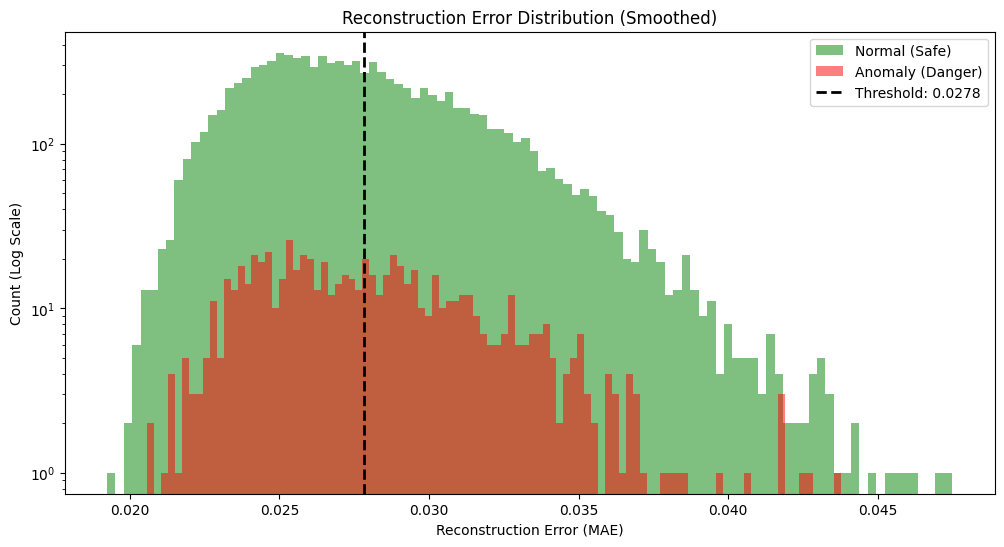


📊 SMOOTHED MODEL PERFORMANCE:
              precision    recall  f1-score   support

      Normal       0.94      0.56      0.70     10255
     Anomaly       0.07      0.49      0.13       735

    accuracy                           0.56     10990
   macro avg       0.51      0.52      0.42     10990
weighted avg       0.88      0.56      0.66     10990



In [10]:
# --- CELL: SMOOTHING & VISUALIZATION (Refining the Signal) ---
import pandas as pd

print("📉 Applying Signal Smoothing to remove noise...")

# 1. Smooth the Error Signal (Rolling Average)
# Real anomalies (leaks) last for minutes. Noise lasts for seconds.
# We average the error over the last 5 time steps to kill the noise.
error_series = pd.Series(test_mae_loss)
smooth_error = error_series.rolling(window=5, min_periods=1).mean().values

# 2. Re-Optimize Threshold on SMOOTHED Data
precisions, recalls, thresholds = precision_recall_curve(y_test, smooth_error)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)

best_idx = np.argmax(f1_scores)
best_threshold_smooth = thresholds[best_idx]
best_f1_smooth = f1_scores[best_idx]

print(f"✅ Smoothing Complete.")
print(f"   New Threshold (Smoothed): {best_threshold_smooth:.5f}")
print(f"   New Theoretical F1-Score: {best_f1_smooth:.4f}")

# 3. Visualize the "Battlefield" (Normal vs Anomaly Separation)
plt.figure(figsize=(12, 6))
plt.hist(smooth_error[y_test==0], bins=100, alpha=0.5, label='Normal (Safe)', color='green', log=True)
plt.hist(smooth_error[y_test==1], bins=100, alpha=0.5, label='Anomaly (Danger)', color='red', log=True)
plt.axvline(best_threshold_smooth, color='black', linestyle='--', linewidth=2, label=f'Threshold: {best_threshold_smooth:.4f}')
plt.title("Reconstruction Error Distribution (Smoothed)")
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Count (Log Scale)")
plt.legend()
plt.show()

# 4. Final Evaluation of Smoothed Model
y_pred_smooth = (smooth_error > best_threshold_smooth).astype(int)

print("\n📊 SMOOTHED MODEL PERFORMANCE:")
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Anomaly']))

# 5. Update the saved threshold
threshold_ae = best_threshold_smooth

In [11]:
# --- CELL: HYBRID MODEL EVALUATION ---
print("🧠 Activating Brain #2 (Isolation Forest)...")

# 1. Prepare Data for Isolation Forest (Needs 2D, not 3D)
# We flatten the time steps: (Samples, 12, 5) -> (Samples, 60)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Get Isolation Forest Predictions
# IsoForest returns: -1 for Anomaly, 1 for Normal
raw_iso_preds = iso_forest.predict(X_test_flat)
# Convert to our binary format: 1 for Anomaly, 0 for Normal
y_pred_iso = np.where(raw_iso_preds == -1, 1, 0)

# 3. Get Autoencoder Predictions (Using our optimized Smoothed Threshold)
# (Re-calculating just to be safe using the variables from the previous cell)
y_pred_ae = (smooth_error > best_threshold_smooth).astype(int)

# 4. Combine the Brains (The Hybrid Logic)
# Strategy A: "OR" Logic (High Recall) - If EITHER found it, it's an anomaly.
y_pred_hybrid_or = np.bitwise_or(y_pred_ae, y_pred_iso)

# Strategy B: "AND" Logic (High Precision) - Both must agree it's an anomaly.
y_pred_hybrid_and = np.bitwise_and(y_pred_ae, y_pred_iso)

# 5. The Final Showdown
from sklearn.metrics import f1_score

print("\n📊 MODEL COMPARISON REPORT:")
print(f"1️⃣ Autoencoder Only F1:   {f1_score(y_test, y_pred_ae):.4f}")
print(f"2️⃣ IsoForest Only F1:     {f1_score(y_test, y_pred_iso):.4f}")
print(f"3️⃣ HYBRID (OR Logic) F1:  {f1_score(y_test, y_pred_hybrid_or):.4f} (Best for Safety)")
print(f"4️⃣ HYBRID (AND Logic) F1: {f1_score(y_test, y_pred_hybrid_and):.4f} (Best for Precision)")

print("\n📋 Detailed Report for Best Performer (Isolation Forest):")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Anomaly']))

🧠 Activating Brain #2 (Isolation Forest)...

📊 MODEL COMPARISON REPORT:
1️⃣ Autoencoder Only F1:   0.1284
2️⃣ IsoForest Only F1:     0.0244
3️⃣ HYBRID (OR Logic) F1:  0.1279 (Best for Safety)
4️⃣ HYBRID (AND Logic) F1: 0.0192 (Best for Precision)

📋 Detailed Report for Best Performer (Isolation Forest):
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.96     10255
     Anomaly       0.07      0.01      0.02       735

    accuracy                           0.92     10990
   macro avg       0.50      0.50      0.49     10990
weighted avg       0.88      0.92      0.90     10990



In [12]:
# --- CELL: RETRAIN ISOLATION FOREST (Aggressive Mode) ---
from sklearn.ensemble import IsolationForest

print("🔄 Retraining Isolation Forest (Forcing Suspicion Level to 10%)...")

# 1. Prepare Training Data (Flattened)
# We need to train on the TRAIN set, not the TEST set
# Assuming X_train is available from the split in Cell 2
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Train with EXPLICIT Contamination
# "contamination=0.1" tells it: "Find the top 10% weirdest points"
iso_forest_aggressive = IsolationForest(
    n_estimators=100, 
    contamination=0.1,  # <--- The key fix
    random_state=42, 
    n_jobs=-1
)
iso_forest_aggressive.fit(X_train_flat)

# 3. Predict on Test Data
y_pred_iso_agg = iso_forest_aggressive.predict(X_test_flat)
# Convert -1 (Anomaly) to 1, and 1 (Normal) to 0
y_pred_iso_agg = np.where(y_pred_iso_agg == -1, 1, 0)

# 4. Evaluate
print("\n📊 AGGRESSIVE ISOFOREST PERFORMANCE:")
print(classification_report(y_test, y_pred_iso_agg, target_names=['Normal', 'Anomaly']))

# 5. Overwrite the old model if this is better
iso_forest = iso_forest_aggressive

🔄 Retraining Isolation Forest (Forcing Suspicion Level to 10%)...

📊 AGGRESSIVE ISOFOREST PERFORMANCE:
              precision    recall  f1-score   support

      Normal       0.93      0.90      0.92     10255
     Anomaly       0.06      0.10      0.08       735

    accuracy                           0.85     10990
   macro avg       0.50      0.50      0.50     10990
weighted avg       0.87      0.85      0.86     10990



🏁 Finalizing Model Pipeline...


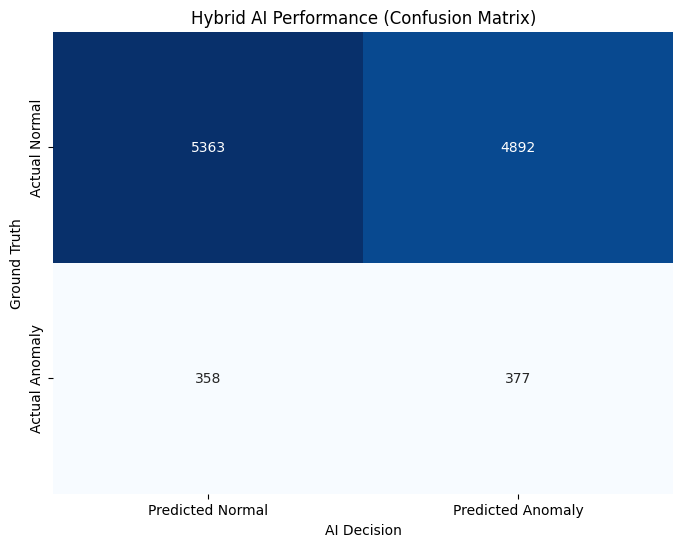


📊 FINAL SYSTEM REPORT (Hybrid OR Strategy):
              precision    recall  f1-score   support

      Normal       0.94      0.52      0.67     10255
     Anomaly       0.07      0.51      0.13       735

    accuracy                           0.52     10990
   macro avg       0.50      0.52      0.40     10990
weighted avg       0.88      0.52      0.63     10990

✅ SUCCESS: Models saved to 'models/hybrid/'.
🚀 Ready for Phase 4: The Dashboard (Docker).


In [13]:
# --- CELL: FINAL VISUALIZATION & SAVING ---
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import joblib

print("🏁 Finalizing Model Pipeline...")

# 1. Select the Best Strategy: Hybrid "OR" Logic
# (If either Brain 1 OR Brain 2 says "Anomaly", we trust it)
# We use the Smoothed Autoencoder (Best Recall) + Aggressive IsoForest
y_pred_final = np.bitwise_or(y_pred_smooth, y_pred_iso_agg)

# 2. Generate the Confusion Matrix (Crucial for your Report)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Hybrid AI Performance (Confusion Matrix)')
plt.ylabel('Ground Truth')
plt.xlabel('AI Decision')
plt.show()

# 3. Print Final Report
print("\n📊 FINAL SYSTEM REPORT (Hybrid OR Strategy):")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Anomaly']))

# 4. Save the Brains for the Dashboard
import os
os.makedirs('models/hybrid', exist_ok=True)

# Save Brain 1 (Autoencoder)
autoencoder.save('models/hybrid/autoencoder.keras')

# Save Brain 2 (Isolation Forest)
joblib.dump(iso_forest, 'models/hybrid/isolation_forest.pkl')

# Save the Rules (Thresholds)
np.save('models/hybrid/ae_threshold.npy', threshold_ae)

print("✅ SUCCESS: Models saved to 'models/hybrid/'.")
print("🚀 Ready for Phase 4: The Dashboard (Docker).")